In [1]:
import re
import numpy as np
import pandas as pd
from datetime import date
from google.cloud import bigquery
import warnings
warnings.filterwarnings("ignore", message="BigQuery Storage module not found")

pd.options.plotting.backend = "plotly"
bq_client = bigquery.Client()

In [23]:
project = "warehouse-390509"
dataset_id = "Public_Data"
keyword = "price"

# List all the available tables in the warehouse matching a specific regex

def search_tables(project, dataset_id, keyword):
    dataset_ref = bq_client.dataset(dataset_id, project=project)
    pattern = re.compile(keyword, re.IGNORECASE)
    rows = []
    for table in bq_client.list_tables(dataset_ref):
        if pattern.search(table.table_id):
            rows.append({
                "dataset": dataset_id,
                "table":   table.table_id,
                "type":    table.table_type,
                "full_id": f"{project}.{dataset_id}.{table.table_id}",
            })
    df_tables = pd.DataFrame(rows)
    print(f"Found {len(df_tables)} matching tables")
    return df_tables

search_tables(project, dataset_id, keyword)

Found 32 matching tables


,dataset,table,type,full_id
0,Public_Data,entsoe_balancing_clearing_prices_afrr,TABLE,warehouse-390509.Public_Data.entsoe_balancing_...
1,Public_Data,entsoe_balancing_imbalance_prices,TABLE,warehouse-390509.Public_Data.entsoe_balancing_...
2,Public_Data,entsoe_balancing_prices_activated_energy,TABLE,warehouse-390509.Public_Data.entsoe_balancing_...
3,Public_Data,entsoe_market_dayahead_prices,TABLE,warehouse-390509.Public_Data.entsoe_market_day...
4,Public_Data,fingrid_afrr_capacity_price_down,TABLE,warehouse-390509.Public_Data.fingrid_afrr_capa...
5,Public_Data,fingrid_afrr_capacity_price_down__tmp_069861b8,TABLE,warehouse-390509.Public_Data.fingrid_afrr_capa...
6,Public_Data,fingrid_afrr_capacity_price_up,TABLE,warehouse-390509.Public_Data.fingrid_afrr_capa...
7,Public_Data,fingrid_be_downreg_price,TABLE,warehouse-390509.Public_Data.fingrid_be_downre...
8,Public_Data,fingrid_be_upreg_price,TABLE,warehouse-390509.Public_Data.fingrid_be_upreg_...
9,Public_Data,fingrid_fcr_d_down_price,TABLE,warehouse-390509.Public_Data.fingrid_fcr_d_dow...


In [24]:
table_id = "entsoe_market_dayahead_prices"

In [25]:
today = date.today()
zone = 'FI'

QUERY = f"""
    SELECT delivery_date, spot_price
    FROM `{project}.{dataset_id}.{table_id}`
    WHERE zone = '{zone}'
    ORDER BY delivery_date ASC
"""

df = bq_client.query(QUERY, location="eu").to_dataframe().set_index("delivery_date")
df.index = df.index.tz_convert("Europe/Paris")
df

,spot_price
delivery_date,
2020-01-01 00:00:00+01:00,28.78
2020-01-01 01:00:00+01:00,28.45
2020-01-01 02:00:00+01:00,27.90
2020-01-01 03:00:00+01:00,27.52
2020-01-01 04:00:00+01:00,27.54
...,...
2026-06-30 22:45:00+02:00,31.83
2026-06-30 23:00:00+02:00,37.61
2026-06-30 23:15:00+02:00,35.97


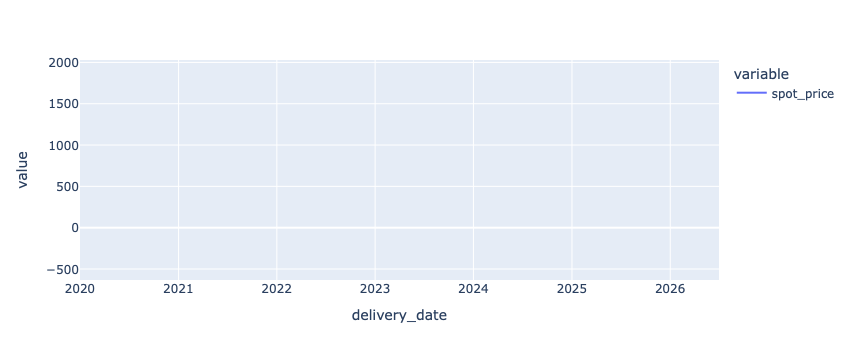

In [26]:
df.plot()

In [ ]:
df[df['delivery_date']==]